In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score, recall_score,f1_score, classification_report, confusion_matrix
import re

In [3]:
df = pd.read_csv("IMDB_Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [7]:
df.isnull().sum()

,0
review,0
sentiment,0


In [8]:
df = df.dropna()

In [9]:
def preprocess_text(text):
  text = re.sub('<.*?>','',text)
  text = re.sub('[^a-zA-Z]',' ',text)
  text = re.sub(r'\s+',' ',text)
  text = text.lower()
  return text

In [10]:
df['clean_review']= df['review'].apply(preprocess_text)


In [12]:
df[['review','clean_review']].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically there s a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei s love in the time of money is a...


In [13]:
df['sentiment'] = df['sentiment'].map({
    'negative':0,
    'positive':1
})

In [17]:
#feature and labels
X= df['review']
y = df['sentiment']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = 42,
    stratify=y
)

print("training samples :", len(X_train))
print("testing samples :", len(X_test))

training samples : 40000
testing samples : 10000


In [22]:
tfidf = TfidfVectorizer(stop_words='english', max_features=50000, ngram_range=(1,2), min_df=2)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [23]:
print("Training TF-IDF shape :",X_train_tfidf.shape)
print("Testing TF-IDF shape :",X_test_tfidf.shape)

Training TF-IDF shape : (40000, 50000)
Testing TF-IDF shape : (10000, 50000)


In [28]:
#Naive bayes classifier
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [26]:
nb_pred= nb_model.predict(X_test_tfidf)

In [29]:
#Evaluate Naive bayes
nb_accuracy = accuracy_score(y_test, nb_pred)
print("Naive bayes accuracy :",nb_accuracy)
nb_precision = precision_score(y_test, nb_pred)
print("Naive bayes precision :",nb_precision)
nb_recall = recall_score(y_test, nb_pred)
print("Naive bayes recall :",nb_recall)
nb_f1 = f1_score(y_test, nb_pred)
print("Naive bayes f1 score :",nb_f1)

Naive bayes accuracy : 0.8787
Naive bayes precision : 0.8731034482758621
Naive bayes recall : 0.8862
Naive bayes f1 score : 0.8796029776674938


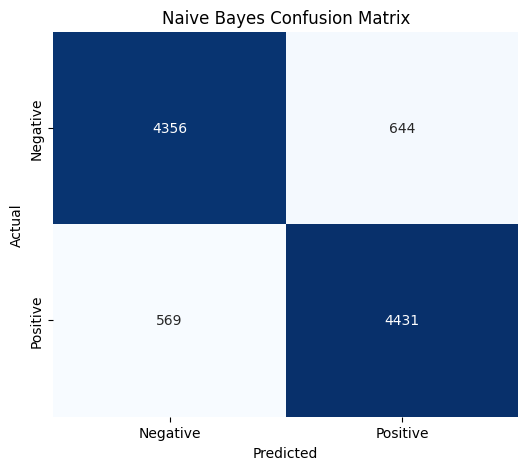

In [30]:
cm_nb = confusion_matrix(y_test, nb_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

In [31]:
#Logistic Regression

lr_model = LogisticRegression(max_iter = 1000, random_state = 42)
lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [32]:
lr_pred = lr_model.predict(X_test_tfidf)

In [33]:
lr_accuracy = accuracy_score(y_test, lr_pred)
print("Logistic Regression accuracy :",lr_accuracy)
lr_precision = precision_score(y_test, lr_pred)
print("Logistic Regression precision :",lr_precision)
lr_recall = recall_score(y_test, lr_pred)
print("Logistic Regression recall :",lr_recall)
lr_f1 = f1_score(y_test, lr_pred)
print("Logistic Regression f1 score :",lr_f1)

Logistic Regression accuracy : 0.902
Logistic Regression precision : 0.8936545240893067
Logistic Regression recall : 0.9126
Logistic Regression f1 score : 0.9030279042153176


Text(0.5, 1.0, 'Logistic Regression-IMDB Confusion Matrix')

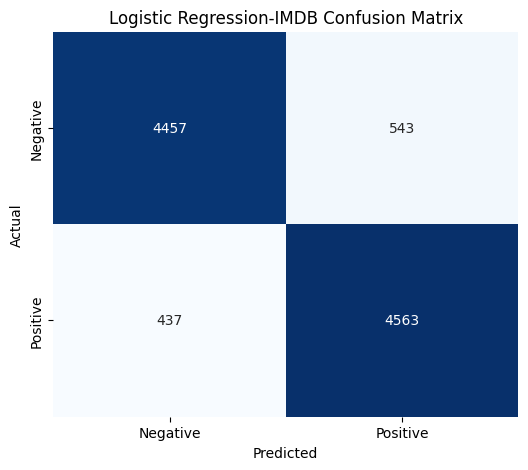

In [34]:
cm_lr = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression-IMDB Confusion Matrix')


In [35]:
print("Naïve Bayes Classification Report")
print(classification_report(
    y_test,
    nb_pred,
    target_names=['Negative', 'Positive']
))

print("Logistic Regression Classification Report")
print(classification_report(
    y_test,
    lr_pred,
    target_names=['Negative', 'Positive']
))

Naïve Bayes Classification Report
              precision    recall  f1-score   support

    Negative       0.88      0.87      0.88      5000
    Positive       0.87      0.89      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

Logistic Regression Classification Report
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      5000
    Positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [37]:
results = pd.DataFrame({ 'Model': [ 'Naïve Bayes', 'Logistic Regression' ], 'Accuracy': [ nb_accuracy, lr_accuracy ], 'Precision': [ nb_precision, lr_precision ], 'Recall': [ nb_recall, lr_recall ], 'F1-score': [ nb_f1, lr_f1 ] })
print(results)

                 Model  Accuracy  Precision  Recall  F1-score
0          Naïve Bayes    0.8787   0.873103  0.8862  0.879603
1  Logistic Regression    0.9020   0.893655  0.9126  0.903028


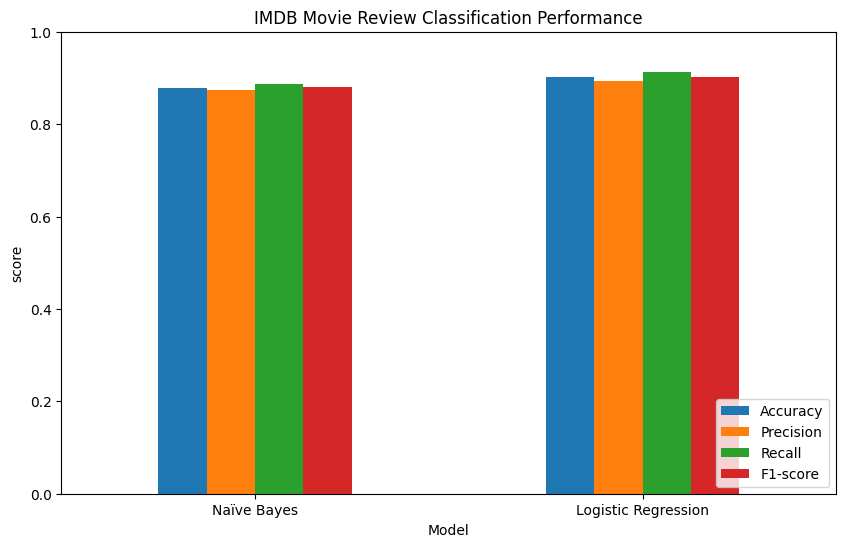

In [39]:
results.set_index('Model').plot(
    kind ='bar',
    figsize =(10,6)
)

plt.title("IMDB Movie Review Classification Performance")
plt.ylabel("score")
plt.ylim(0,1)
plt.xticks(rotation = 0)
plt.legend(loc = 'lower right')
plt.show()

In [40]:
new_review = [ "The movie was absolutely fantastic and the acting was excellent." ]
new_review_tfidf = tfidf.transform(new_review)
prediction = lr_model.predict(new_review_tfidf)
if prediction[0] == 1:
   print("Prediction: Positive")
else:
   print("Prediction: Negative")

Prediction: Positive


In [41]:
new_review = [ "The movie was boring, predictable and poorly acted." ]
new_review_tfidf = tfidf.transform(new_review)
prediction = lr_model.predict(new_review_tfidf)
if prediction[0] == 1:
   print("Prediction: Positive")
else:
   print("Prediction: Negative")


Prediction: Negative
